# Synthetic-100 regression: linear MiSTIC rank-weight sweep

This notebook sweeps `combined_rank(weight=...)` from 0.75 through 1.00 for
the current linear-kernel MiSTIC regression configuration. The ensemble size is
fixed at 20 members and each weight is evaluated with the same ten inner seeds
and fixed blind set.

All other settings are unchanged: forward-knee selection,
`addition_factor=0.1`, `max_features=20`, separate feature sets and parameters,
no per-step tuning, final knee retuning, and C/epsilon tuning for the linear
SVR. Existing sklearn references are loaded only for contextual plots and are
not used to choose the rank weight.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [5, 10, 20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=20.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.10 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=0, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models, rank_weight):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type="linear"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [
        paramSet(model={"C": c, "epsilon": epsilon}, kernel={})
        for c in C_VALUES for epsilon in EPSILON_VALUES
    ]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=rank_weight).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run the rank-weight sweep

Every weight uses exactly the same ten inner seeds. This permits paired
comparisons of blind performance and makes changes in signal recovery, feature
count, and residual diversity directly comparable.


In [4]:
RANK_WEIGHTS = [0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
NUM_MODELS = 20
rows = []

for rank_weight in RANK_WEIGHTS:
    for seed in INNER_SEEDS:
        started = time.perf_counter()
        scaler, ensemble, knee_count = fit_mistic(seed, NUM_MODELS, rank_weight)
        X_blind_scaled = scaler.transform(X_blind)
        predictions = ensemble.predict(X_blind_scaled)
        top20 = ranked_unified_features(ensemble, 20)
        recall, precision = recovery(top20)
        selected_counts = np.asarray([len(f) for f in ensemble.features])
        member_predictions = np.column_stack([
            ensemble.predict(X_blind_scaled, model_index=i)
            for i in range(NUM_MODELS)
        ])
        residuals = np.asarray(y_blind)[:, None] - member_predictions
        residual_correlations = [
            abs(np.corrcoef(residuals[:, i], residuals[:, j])[0, 1])
            for i in range(NUM_MODELS) for j in range(i + 1, NUM_MODELS)
        ]
        rows.append({
            "seed": seed, "rank_weight": rank_weight,
            "method": f"Linear MiSTIC, weight={rank_weight:.2f}",
            "num_models": NUM_MODELS,
            "knee_feature_count": knee_count,
            "mean_member_features": selected_counts.mean(),
            "min_member_features": selected_counts.min(),
            "max_member_features": selected_counts.max(),
            "num_unified_features": len(ensemble.unified_features),
            "top20_signal_recall": recall,
            "top20_signal_precision": precision,
            "member_disagreement": 1 - np.mean(residual_correlations),
            "elapsed_seconds": time.perf_counter() - started,
            **metric_row(y_blind, predictions),
        })
        print(f"weight={rank_weight:.2f}, seed={seed}, knee={knee_count}, "
              f"elapsed={rows[-1]['elapsed_seconds']:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_linear_rank_weight_sweep_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.093


Number of Features: 10, Score: 0.811


Number of Features: 19, Score: 0.972


Number of Features: 20, Score: 0.974


Number of Features: 100, Score: 0.967


...

Number of Features: 19, Score: 0.978


Number of Features: 20, Score: 0.978


Number of Features: 100, Score: 0.967


weight=1.00, seed=9, knee=10, elapsed=23.2s


,seed,rank_weight,method,num_models,knee_feature_count,mean_member_features,min_member_features,max_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,elapsed_seconds,r2,rmse,mae,pearson_r2
0,0,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,70,0.80,0.800000,0.258848,21.565543,0.971690,0.144187,0.112520,0.971770
1,1,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,72,0.90,0.900000,0.239339,20.504489,0.970300,0.147685,0.113769,0.970433
2,2,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,71,0.90,0.900000,0.231155,28.400216,0.970721,0.146635,0.113194,0.970851
3,3,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,65,0.85,0.850000,0.221873,28.150244,0.973362,0.139865,0.109249,0.973444
4,4,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,66,0.85,0.850000,0.271563,26.898657,0.969873,0.148743,0.114369,0.969949
5,5,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,68,0.85,0.850000,0.205502,21.860747,0.971978,0.143452,0.111813,0.972105
6,6,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,70,0.80,0.800000,0.300082,27.020353,0.970916,0.146146,0.114955,0.971027
7,7,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,70,0.80,0.800000,0.300360,29.793478,0.971495,0.144684,0.113896,0.971505
8,8,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,72,0.80,0.800000,0.251380,30.503210,0.973359,0.139874,0.110458,0.973490
9,9,0.75,"Linear MiSTIC, weight=0.75",20,19,19.0,19,19,71,0.85,0.850000,0.251963,26.605932,0.971916,0.143610,0.112466,0.972008


In [5]:
metrics = ["r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
           "mean_member_features", "num_unified_features", "top20_signal_recall",
           "top20_signal_precision", "member_disagreement", "elapsed_seconds"]
summary = results.groupby("rank_weight")[metrics].agg(["mean", "std"])
summary.round(4)


r2            rmse             mae         pearson_r2  \
               mean     std    mean     std    mean     std       mean   
rank_weight                                                              
0.75         0.9716  0.0012  0.1445  0.0030  0.1127  0.0018     0.9717   
0.80         0.9681  0.0097  0.1517  0.0213  0.1191  0.0181     0.9684   
0.85         0.9514  0.0036  0.1889  0.0068  0.1479  0.0063     0.9515   
0.90         0.9523  0.0027  0.1872  0.0054  0.1444  0.0051     0.9525   
0.95         0.9496  0.0051  0.1922  0.0098  0.1461  0.0080     0.9500   
1.00         0.9471  0.0032  0.1970  0.0061  0.1494  0.0051     0.9476   

                    knee_feature_count          ... num_unified_features  \
                std               mean     std  ...                 mean   
rank_weight                                     ...                        
0.75         0.0012               19.0  0.0000  ...                 69.5   
0.80         0.0095               17.2  3.7947  ...                 56.6   
0.85         0.0036               10.0  0.0000  ...                 24.4   
0.90         0.0027               10.0  0.0000  ...                 21.0   
0.95         0.0050               10.0  0.0000  ...                 17.8   
1.00         0.0032               10.0  0.0000  ...                 16.3   

                     top20_signal_recall         top20_signal_precision  \
                 std                mean     std                   mean   
rank_weight                                                               
0.75          2.4152               0.840  0.0394                 0.8400   
0.80         16.4330               0.845  0.0599                 0.8450   
0.85          2.5473               0.765  0.0242                 0.7650   
0.90          1.7638               0.740  0.0211                 0.7524   
0.95          1.6865               0.690  0.0394                 0.7839   
1.00          0.6749               0.650  0.0236                 0.7984   

                    member_disagreement         elapsed_seconds          
                std                mean     std            mean     std  
rank_weight                                                              
0.75         0.0394              0.2532  0.0311         26.1303  3.5606  
0.80         0.0599              0.2373  0.1313         25.5132  2.8731  
0.85         0.0242              0.3830  0.0586         23.4359  2.8133  
0.90         0.0295              0.2614  0.0447         22.5101  2.8892  
0.95         0.0691              0.1205  0.0483         23.3072  3.5897  
1.00         0.0353              0.0874  0.0134         24.3905  2.1775  

[6 rows x 22 columns]

In [6]:
baseline = results.query("rank_weight == 0.90").set_index("seed")
paired_rows = []
for weight in RANK_WEIGHTS:
    if np.isclose(weight, 0.90):
        continue
    candidate = results.query("rank_weight == @weight").set_index("seed")
    for metric in ["r2", "rmse", "mae", "pearson_r2"]:
        improvement = candidate[metric] - baseline[metric]
        if metric in ["rmse", "mae"]:
            improvement = -improvement
        paired_rows.append({
            "comparison": f"weight {weight:.2f} minus 0.90", "metric": metric,
            "mean_improvement": improvement.mean(),
            "std_improvement": improvement.std(ddof=1),
            "candidate_wins": int((improvement > 0).sum()),
            "ties": int((improvement == 0).sum()),
            "candidate_losses": int((improvement < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
paired.round(4)


,comparison,metric,mean_improvement,std_improvement,candidate_wins,ties,candidate_losses
0,weight 0.75 minus 0.90,r2,0.0193,0.0033,10,0,0
1,weight 0.75 minus 0.90,rmse,0.0427,0.0069,10,0,0
2,weight 0.75 minus 0.90,mae,0.0317,0.0058,10,0,0
3,weight 0.75 minus 0.90,pearson_r2,0.0191,0.0032,10,0,0
4,weight 0.80 minus 0.90,r2,0.0158,0.0111,8,0,2
5,weight 0.80 minus 0.90,rmse,0.0355,0.0241,8,0,2
6,weight 0.80 minus 0.90,mae,0.0253,0.0206,8,0,2
7,weight 0.80 minus 0.90,pearson_r2,0.0159,0.0108,8,0,2
8,weight 0.85 minus 0.90,r2,-0.0009,0.0038,5,0,5
9,weight 0.85 minus 0.90,rmse,-0.0017,0.0073,5,0,5


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_77754/3863813440.py:26: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=comparison, y="method", x="r2", order=order,


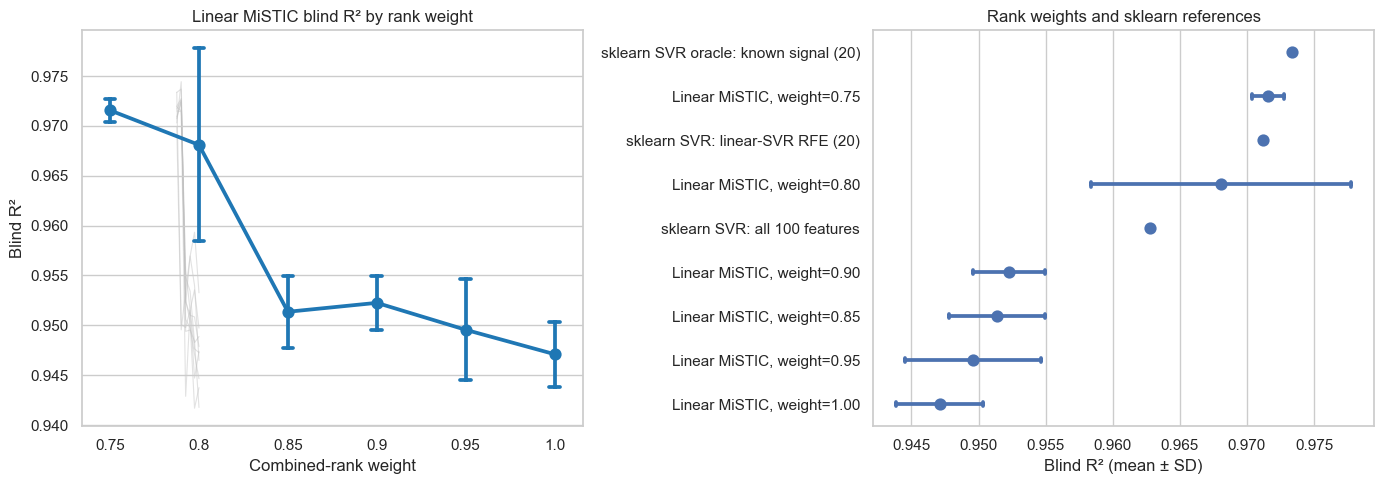

In [7]:
reference_results = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_linear_member_count_10seeds_results.csv"
)
reference_names = [
    "sklearn SVR oracle: known signal (20)",
    "sklearn SVR: linear-SVR RFE (20)",
    "sklearn SVR: all 100 features",
]
references = reference_results[reference_results["method"].isin(reference_names)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.pointplot(data=results, x="rank_weight", y="r2", errorbar="sd",
              capsize=0.12, color="tab:blue", ax=axes[0])
for _, seed_data in results.groupby("seed"):
    axes[0].plot(seed_data["rank_weight"], seed_data["r2"],
                 color="0.75", alpha=0.45, linewidth=0.8, zorder=0)
axes[0].set_title("Linear MiSTIC blind R² by rank weight")
axes[0].set_xlabel("Combined-rank weight")
axes[0].set_ylabel("Blind R²")

comparison = pd.concat([
    results[["seed", "method", "r2"]],
    references[["seed", "method", "r2"]],
], ignore_index=True)
order = comparison.groupby("method")["r2"].mean().sort_values(ascending=False).index
sns.pointplot(data=comparison, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.10, ax=axes[1])
axes[1].set_title("Rank weights and sklearn references")
axes[1].set_xlabel("Blind R² (mean ± SD)")
axes[1].set_ylabel("")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_linear_rank_weight_sweep_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

Blind performance is reported to evaluate the experiment, but it must not be
used operationally to select a weight. The table also reports internal feature
count and signal-recovery behavior. All ten runs reuse one blind set, so their
variation reflects inner model construction rather than independent test-set
uncertainty.
